# Restaurant Revenue Prediction Using Machine Learning

## Project Overview


**Business Problem**

A company owns data about existing restaurants, and every restaurant has different characteristics (number of customers, menu price, marketing spend, cuisine type, average customer spending, seating capacity, promotions, and reviews).

Opening a new restaurant is expensive, and the business owner wants to **estimate the expected revenue before investing**. This project builds a Machine Learning model that learns from historical restaurant data, so that when we enter the details of a new restaurant, the model predicts its **expected monthly revenue**.

**Project Type:** Regression (we are predicting a continuous numeric value — the revenue).

**Goals**
- Explore and understand the restaurant data.
- Clean the data (missing values, duplicates, outliers).
- Engineer useful features.
- Train and compare several regression models.
- Tune the best model and evaluate it properly.
- Save the best model so it can be used in a web app.


##  Import Libraries

In [117]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings("ignore")

##  Data Loading

In [118]:
df = pd.read_csv("Restaurant_Revenue_Dataset.csv")

In [119]:
df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Seating_Capacity,Promotions,Reviews,Monthly_Revenue
0,195,40.10,2993.97,Japanese,57.99,46,1,260.0,57286.84
1,216,59.56,529.66,Mexican,30.48,119,0,151.0,37539.15
2,45,54.95,358.41,American,22.18,140,0,200.0,10173.33
3,87,27.68,2012.48,Italian,45.26,20,0,390.0,20599.60
4,231,9.99,825.10,Mexican,31.22,188,0,465.0,28541.09


In [120]:
df.shape

(1208, 9)

In [121]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1208 entries, 0 to 1207
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number_of_Customers        1208 non-null   int64  
 1   Menu_Price                 1208 non-null   float64
 2   Marketing_Spend            1198 non-null   float64
 3   Cuisine_Type               1208 non-null   str    
 4   Average_Customer_Spending  1208 non-null   float64
 5   Seating_Capacity           1208 non-null   int64  
 6   Promotions                 1208 non-null   int64  
 7   Reviews                    1193 non-null   float64
 8   Monthly_Revenue            1208 non-null   float64
dtypes: float64(5), int64(3), str(1)
memory usage: 93.7 KB


##  Exploratory Data Analysis (EDA)

In [122]:
df.describe()

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Seating_Capacity,Promotions,Reviews,Monthly_Revenue
count,1208.000000,1208.000000,1198.000000,1208.000000,1208.000000,1208.000000,1193.000000,1208.000000
mean,157.254967,34.414222,1539.880676,33.574214,105.776490,0.495033,249.844091,28524.798891
std,80.580287,15.152665,843.193459,14.775554,52.215725,0.500182,147.047597,18625.450064
min,20.000000,8.000000,50.720000,8.020000,20.000000,0.000000,0.000000,500.000000
25%,88.750000,21.800000,801.800000,20.745000,59.000000,0.000000,123.000000,13234.455000
50%,154.500000,34.795000,1555.560000,33.510000,105.000000,0.000000,252.000000,25384.220000
75%,228.000000,48.170000,2263.085000,46.890000,151.000000,1.000000,377.000000,40388.655000
max,299.000000,59.960000,2998.740000,59.980000,199.000000,1.000000,499.000000,88945.470000


In [123]:
df.nunique()

Number_of_Customers           273
Menu_Price                   1088
Marketing_Spend              1187
Cuisine_Type                    5
Average_Customer_Spending    1069
Seating_Capacity              178
Promotions                      2
Reviews                       446
Monthly_Revenue              1182
dtype: int64

In [124]:
df["Cuisine_Type"].value_counts()

Cuisine_Type
American    290
Mexican     246
Japanese    239
Italian     238
Indian      195
Name: count, dtype: int64

In [125]:
df.corr(numeric_only=True)

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Seating_Capacity,Promotions,Reviews,Monthly_Revenue
Number_of_Customers,1.000000,-0.003556,0.012081,-0.024704,-0.001938,0.025027,-0.071731,0.739812
Menu_Price,-0.003556,1.000000,0.002598,-0.036704,-0.024380,-0.031610,-0.012226,0.069235
Marketing_Spend,0.012081,0.002598,1.000000,0.009976,0.000814,0.047326,-0.008946,0.019507
Average_Customer_Spending,-0.024704,-0.036704,0.009976,1.000000,-0.025208,0.010074,-0.042499,0.530281
Seating_Capacity,-0.001938,-0.024380,0.000814,-0.025208,1.000000,-0.015364,0.006202,-0.017234
Promotions,0.025027,-0.031610,0.047326,0.010074,-0.015364,1.000000,0.014681,0.059369
Reviews,-0.071731,-0.012226,-0.008946,-0.042499,0.006202,0.014681,1.000000,-0.066060
Monthly_Revenue,0.739812,0.069235,0.019507,0.530281,-0.017234,0.059369,-0.066060,1.000000


### Revenue Distribution

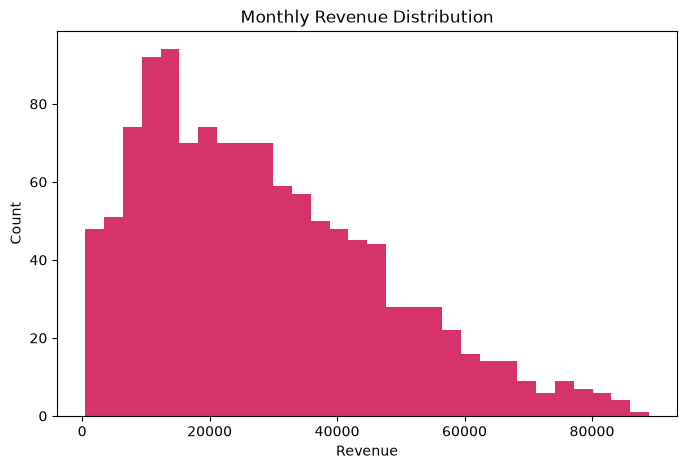

In [126]:
plt.figure(figsize=(8,5))
plt.hist(df["Monthly_Revenue"], bins=30, color="#D6336C")
plt.title("Monthly Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Count")
plt.show()

### Cuisine Type Count

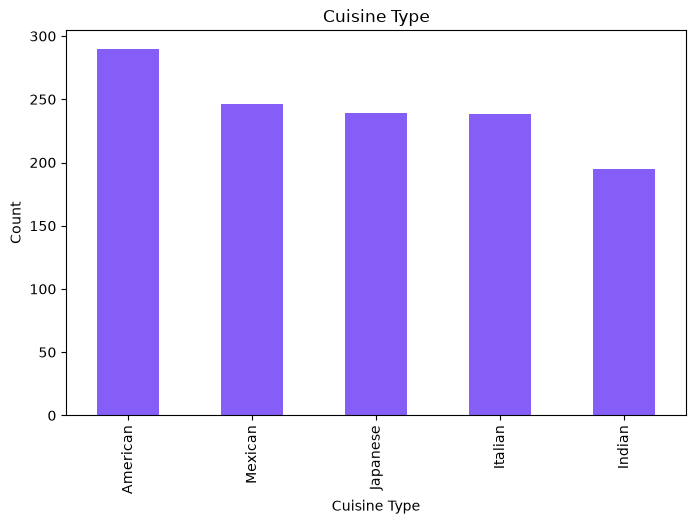

In [127]:
plt.figure(figsize=(8,5))
df["Cuisine_Type"].value_counts().plot(kind="bar", color="#845EF7")
plt.title("Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Count")
plt.show()

### Number of Customers vs Monthly Revenue

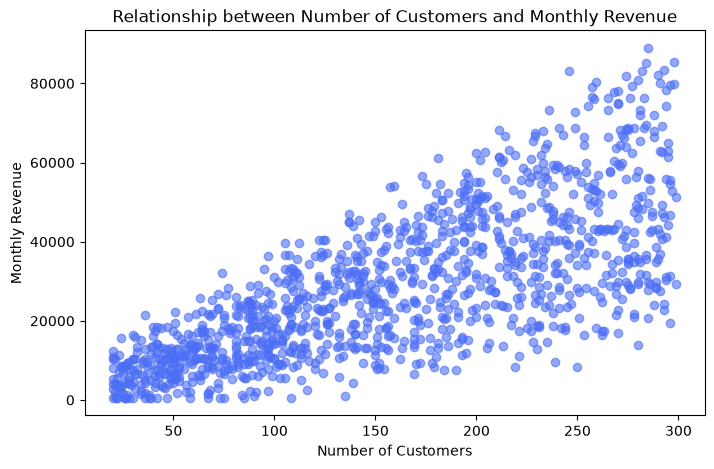

In [128]:
plt.figure(figsize=(8,5))
plt.scatter(df["Number_of_Customers"], df["Monthly_Revenue"], color="#4C6EF5", alpha=0.6)
plt.xlabel("Number of Customers")
plt.ylabel("Monthly Revenue")
plt.title("Relationship between Number of Customers and Monthly Revenue")
plt.show()

### Average Customer Spending vs Monthly Revenue

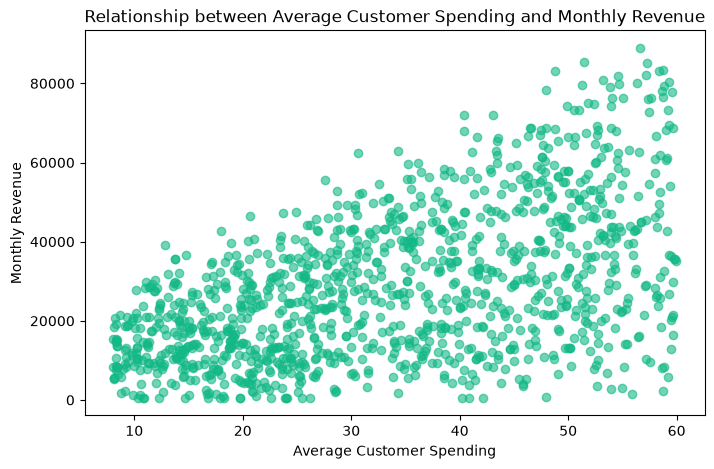

In [129]:
plt.figure(figsize=(8,5))
plt.scatter(df["Average_Customer_Spending"], df["Monthly_Revenue"], color="#12B886", alpha=0.6)
plt.xlabel("Average Customer Spending")
plt.ylabel("Monthly Revenue")
plt.title("Relationship between Average Customer Spending and Monthly Revenue")
plt.show()

### Marketing Spend vs Monthly Revenue

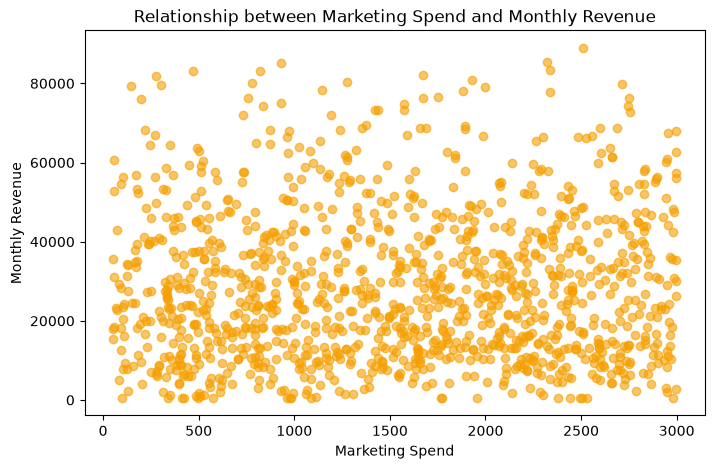

In [130]:
plt.figure(figsize=(8,5))
plt.scatter(df["Marketing_Spend"], df["Monthly_Revenue"], color="#F59F00", alpha=0.6)
plt.xlabel("Marketing Spend")
plt.ylabel("Monthly Revenue")
plt.title("Relationship between Marketing Spend and Monthly Revenue")
plt.show()

### Heatmap

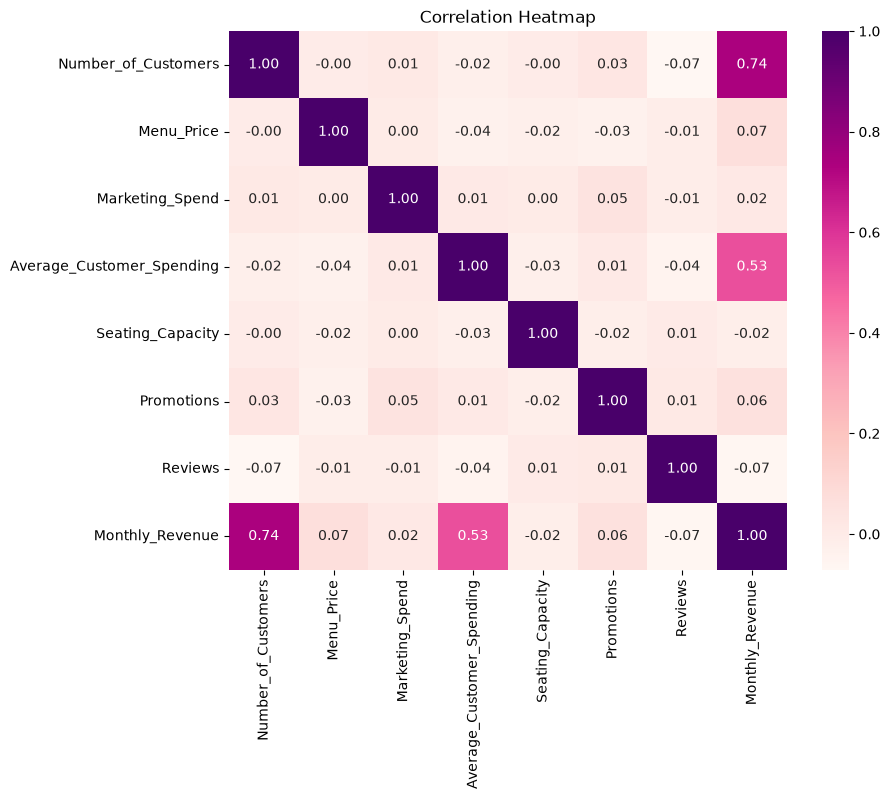

In [131]:
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="RdPu", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

##  Data Cleaning

### Missing Values

In [132]:
df.isnull().sum()

Number_of_Customers           0
Menu_Price                    0
Marketing_Spend              10
Cuisine_Type                  0
Average_Customer_Spending     0
Seating_Capacity              0
Promotions                    0
Reviews                      15
Monthly_Revenue               0
dtype: int64

In [133]:
df["Reviews"] = df["Reviews"].fillna(df["Reviews"].median())
df["Marketing_Spend"] = df["Marketing_Spend"].fillna(df["Marketing_Spend"].median())

In [134]:
df.isnull().sum()

Number_of_Customers          0
Menu_Price                   0
Marketing_Spend              0
Cuisine_Type                 0
Average_Customer_Spending    0
Seating_Capacity             0
Promotions                   0
Reviews                      0
Monthly_Revenue              0
dtype: int64

### Duplicates

In [135]:
df.duplicated().sum()

np.int64(8)

In [136]:
df.drop_duplicates(inplace=True)

In [137]:
df.shape

(1200, 9)

### Outliers

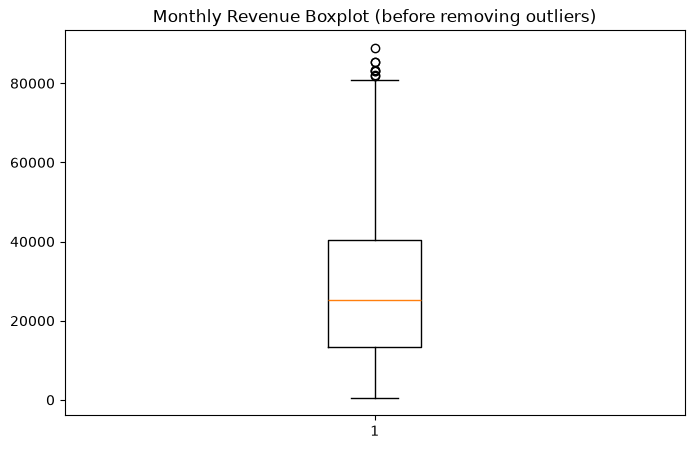

In [138]:
plt.figure(figsize=(8,5))
plt.boxplot(df["Monthly_Revenue"])
plt.title("Monthly Revenue Boxplot (before removing outliers)")
plt.show()

In [139]:
# Interquartile Range (IQR) method
Q1 = df["Monthly_Revenue"].quantile(0.25)
Q3 = df["Monthly_Revenue"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower bound =", lower_bound)
print("Upper bound =", upper_bound)

Lower bound = -27424.89875
Upper bound = 81011.91125


In [140]:
df = df[(df["Monthly_Revenue"] >= lower_bound) & (df["Monthly_Revenue"] <= upper_bound)]
df.shape

(1192, 9)

##  Feature Engineering



In [141]:
df["Customers_x_Spending"] = df["Number_of_Customers"] * df["Average_Customer_Spending"]

In [142]:
df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Seating_Capacity,Promotions,Reviews,Monthly_Revenue,Customers_x_Spending
0,195,40.10,2993.97,Japanese,57.99,46,1,260.0,57286.84,11308.05
1,216,59.56,529.66,Mexican,30.48,119,0,151.0,37539.15,6583.68
2,45,54.95,358.41,American,22.18,140,0,200.0,10173.33,998.10
3,87,27.68,2012.48,Italian,45.26,20,0,390.0,20599.60,3937.62
4,231,9.99,825.10,Mexican,31.22,188,0,465.0,28541.09,7211.82


##  Encoding

In [143]:
# Cuisine_Type is categorical, so we convert it into numerical format using one-hot encoding
df = pd.get_dummies(df, columns=["Cuisine_Type"], drop_first=True)

In [144]:
df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Seating_Capacity,Promotions,Reviews,Monthly_Revenue,Customers_x_Spending,Cuisine_Type_Indian,Cuisine_Type_Italian,Cuisine_Type_Japanese,Cuisine_Type_Mexican
0,195,40.10,2993.97,57.99,46,1,260.0,57286.84,11308.05,False,False,True,False
1,216,59.56,529.66,30.48,119,0,151.0,37539.15,6583.68,False,False,False,True
2,45,54.95,358.41,22.18,140,0,200.0,10173.33,998.10,False,False,False,False
3,87,27.68,2012.48,45.26,20,0,390.0,20599.60,3937.62,False,True,False,False
4,231,9.99,825.10,31.22,188,0,465.0,28541.09,7211.82,False,False,False,True


##  Split Features and Target

In [145]:
X = df.drop("Monthly_Revenue", axis=1)

In [146]:
y = df["Monthly_Revenue"]

##  Train Test Split

In [147]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

##  Feature Scaling

In [148]:
scaler = StandardScaler()

In [149]:
X_train_scaled = scaler.fit_transform(X_train)

In [150]:
X_test_scaled = scaler.transform(X_test)

##  Dimensionality Reduction Using PCA

Before comparing models, we take a look at **Principal Component Analysis (PCA)**.
PCA compresses correlated features into a smaller set of uncorrelated components while keeping as much of the original variance (information) as possible.

We are not going to replace our original scaled features with PCA components for the main models below (our feature set is already small and each feature is meaningful for the business problem), but we do want to **use PCA as a reference tool**: we check how much variance the features actually carry, and we compare model performance with vs. without PCA.

In [151]:
# Fit PCA on the scaled training data, keeping enough components to explain 95% of the variance
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Number of components kept:", pca.n_components_)
print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum())

Number of components kept: 10
Explained variance ratio per component: [0.16183614 0.10862098 0.10590057 0.10071217 0.0907194  0.08643065
 0.08548419 0.07995671 0.07663993 0.07434838]
Total variance explained: 0.9706491301576081


In [152]:
loss = 1 - np.sum(pca.explained_variance_ratio_)
print(f"Loss of information: {loss * 100:.2f}%")

Loss of information: 2.94%


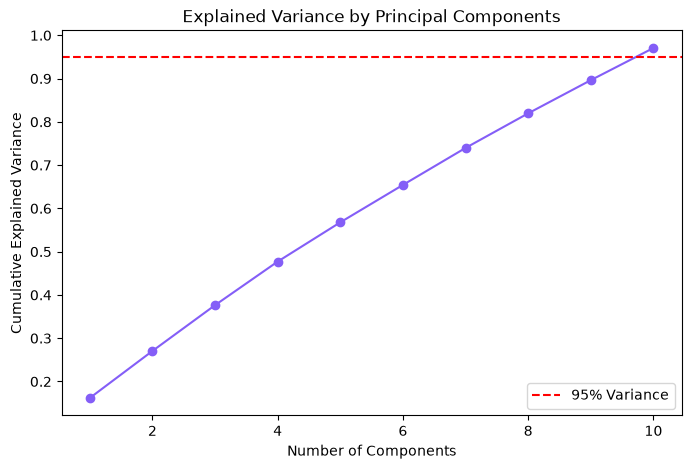

In [153]:
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_var)+1), cum_var, marker="o", color="#845EF7")
plt.axhline(0.95, color="red", linestyle="--", label="95% Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Principal Components")
plt.legend()
plt.show()

**Quick check — does PCA help this dataset?**

We train a Random Forest on the original scaled features and on the PCA components, and compare the R² score. This is only a sanity check; the main model comparison later in the notebook keeps using the original scaled features (`X_train_scaled` / `X_test_scaled`).

In [154]:
# Random Forest without PCA (baseline, using all original scaled features)
rf_pca_check = RandomForestRegressor(n_estimators=300, random_state=42)
rf_pca_check.fit(X_train_scaled, y_train)
r2_before_pca = r2_score(y_test, rf_pca_check.predict(X_test_scaled))

# Random Forest with PCA components
rf_pca_check_pca = RandomForestRegressor(n_estimators=300, random_state=42)
rf_pca_check_pca.fit(X_train_pca, y_train)
r2_after_pca = r2_score(y_test, rf_pca_check_pca.predict(X_test_pca))

print("R2 before PCA:", r2_before_pca)
print("R2 after PCA :", r2_after_pca)

R2 before PCA: 0.9272075095144852
R2 after PCA : 0.9198605163049247


##  Linear Regression Model

In [155]:
lr_model = LinearRegression()

In [156]:
lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[2257.47,1750.21, 295.8 ,..., 127.81, 159.31, 163.57]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.807e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](12,)","[43.02,35.24,34.8 ,...,29.16,16.9 , 7.07]"


### Prediction

In [157]:
lr_pred = lr_model.predict(X_test_scaled)

### Model Evaluation

In [158]:
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("MAE  =", lr_mae)
print("MSE  =", lr_mse)
print("RMSE =", lr_rmse)
print("R2   =", lr_r2)

MAE  = 3782.1490603651164
MSE  = 22239751.633674428
RMSE = 4715.9041162511385
R2   = 0.9383165226759634


### Actual vs Predicted

In [159]:
comparison = pd.DataFrame({"Actual": y_test, "Predicted": lr_pred})
comparison.head(10)

,Actual,Predicted
926,2778.14,3635.726392
248,8224.35,14283.503088
262,47842.51,51409.931881
156,34540.06,36438.094800
570,26986.97,26607.073367
553,13532.15,12057.656439
808,10417.05,7211.759329
58,40816.40,37300.692403
758,79503.52,75661.041694
648,25299.28,22402.865544


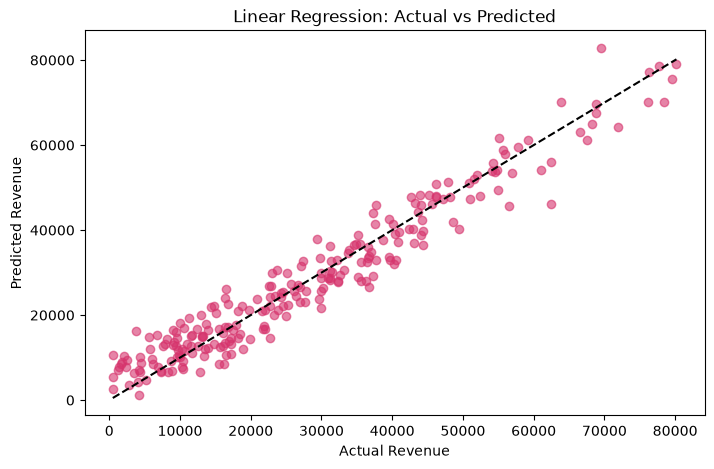

In [160]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, lr_pred, color="#D6336C", alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

##  Decision Tree Regressor

In [161]:
dt_model = DecisionTreeRegressor(max_depth=6, random_state=42)

In [162]:
dt_model.fit(X_train_scaled, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",6
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [163]:
dt_pred = dt_model.predict(X_test_scaled)

In [164]:
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_pred)

print("MAE  =", dt_mae)
print("MSE  =", dt_mse)
print("RMSE =", dt_rmse)
print("R2   =", dt_r2)

MAE  = 4524.003602299845
MSE  = 32140815.672250237
RMSE = 5669.28705149512
R2   = 0.9108552421199979


##  Random Forest Regressor

In [165]:
rf_model = RandomForestRegressor(n_estimators=300, random_state=42)

In [166]:
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [167]:
rf_pred = rf_model.predict(X_test_scaled)

In [168]:
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("MAE  =", rf_mae)
print("MSE  =", rf_mse)
print("RMSE =", rf_rmse)
print("R2   =", rf_r2)

MAE  = 4150.216244072527
MSE  = 26245065.606306475
RMSE = 5122.993812831172
R2   = 0.9272075095144852


##  XGBoost Regressor

In [169]:
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

In [170]:
xgb_model.fit(X_train_scaled, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [171]:
xgb_pred = xgb_model.predict(X_test_scaled)

In [172]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(xgb_mse)
xgb_r2 = r2_score(y_test, xgb_pred)

print("MAE  =", xgb_mae)
print("MSE  =", xgb_mse)
print("RMSE =", xgb_rmse)
print("R2   =", xgb_r2)

MAE  = 4155.428732961232
MSE  = 25968998.27347766
RMSE = 5095.978637462844
R2   = 0.9279732012067732


##  Support Vector Machine (SVM)

In [173]:
svm_model = SVR(kernel="rbf", C=100, epsilon=0.1)

In [174]:
svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [175]:
svm_pred = svm_model.predict(X_test_scaled)

In [176]:
svm_mae = mean_absolute_error(y_test, svm_pred)
svm_mse = mean_squared_error(y_test, svm_pred)
svm_rmse = np.sqrt(svm_mse)
svm_r2 = r2_score(y_test, svm_pred)

print("MAE  =", svm_mae)
print("MSE  =", svm_mse)
print("RMSE =", svm_rmse)
print("R2   =", svm_r2)

MAE  = 12876.689691837348
MSE  = 267352340.10315466
RMSE = 16350.912515916494
R2   = 0.2584799380892905


##  Cross Validation



In [177]:
cv_scores = {
    "Linear Regression": cross_val_score(LinearRegression(), X_train_scaled, y_train, cv=5, scoring="r2"),
    "Decision Tree": cross_val_score(DecisionTreeRegressor(max_depth=6, random_state=42), X_train_scaled, y_train, cv=5, scoring="r2"),
    "Random Forest": cross_val_score(RandomForestRegressor(n_estimators=300, random_state=42), X_train_scaled, y_train, cv=5, scoring="r2"),
    "XGBoost": cross_val_score(XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42), X_train_scaled, y_train, cv=5, scoring="r2"),
    "SVM (SVR)": cross_val_score(SVR(kernel="rbf", C=100, epsilon=0.1), X_train_scaled, y_train, cv=5, scoring="r2"),
}

for name, scores in cv_scores.items():
    print(f"{name}: mean R2 = {scores.mean():.4f}  (std = {scores.std():.4f})")

Linear Regression: mean R2 = 0.9259  (std = 0.0060)
Decision Tree: mean R2 = 0.8842  (std = 0.0131)
Random Forest: mean R2 = 0.9178  (std = 0.0077)
XGBoost: mean R2 = 0.9127  (std = 0.0086)
SVM (SVR): mean R2 = 0.2206  (std = 0.0235)


##  Hyperparameter Tuning



In [178]:
param_grid = {
    "n_estimators": [200, 300, 400],
    "max_depth": [8, 12, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 400}


In [179]:
rf_tuned = grid_search.best_estimator_
rf_tuned_pred = rf_tuned.predict(X_test_scaled)

rf_tuned_mae = mean_absolute_error(y_test, rf_tuned_pred)
rf_tuned_mse = mean_squared_error(y_test, rf_tuned_pred)
rf_tuned_rmse = np.sqrt(rf_tuned_mse)
rf_tuned_r2 = r2_score(y_test, rf_tuned_pred)

print("MAE  =", rf_tuned_mae)
print("MSE  =", rf_tuned_mse)
print("RMSE =", rf_tuned_rmse)
print("R2   =", rf_tuned_r2)

MAE  = 4109.453868500949
MSE  = 25694983.662387006
RMSE = 5069.021963099687
R2   = 0.9287331995344557


##  Feature Importance

In [180]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_tuned.feature_importances_
}).sort_values(by="Importance", ascending=False)

importances

,Feature,Importance
7,Customers_x_Spending,0.939366
1,Menu_Price,0.016746
0,Number_of_Customers,0.014579
6,Reviews,0.007725
2,Marketing_Spend,0.005967
3,Average_Customer_Spending,0.005858
4,Seating_Capacity,0.005620
5,Promotions,0.001864
9,Cuisine_Type_Italian,0.000689
11,Cuisine_Type_Mexican,0.000608


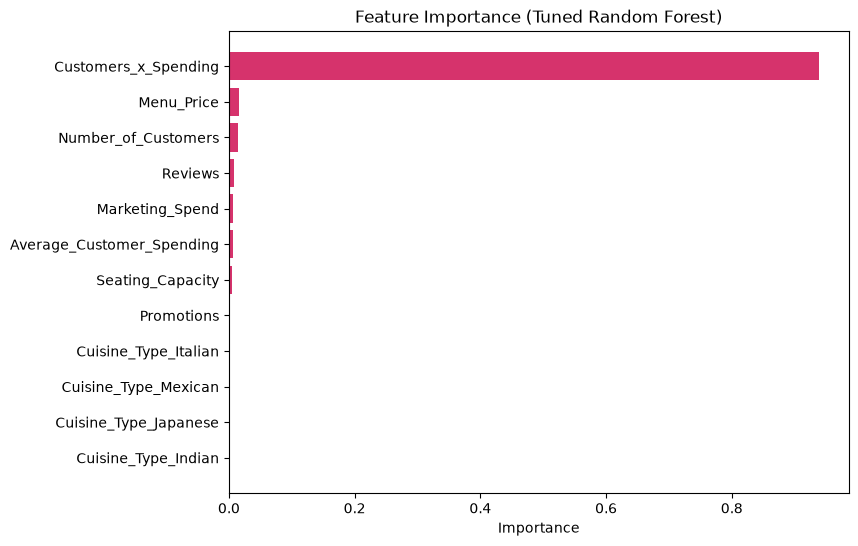

In [181]:
plt.figure(figsize=(8,6))
plt.barh(importances["Feature"], importances["Importance"], color="#D6336C")
plt.gca().invert_yaxis()
plt.title("Feature Importance (Tuned Random Forest)")
plt.xlabel("Importance")
plt.show()

##  Model Comparison

In [182]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "SVM (SVR)",
        "Random Forest (Tuned)"
    ],
    "MAE": [lr_mae, dt_mae, rf_mae, xgb_mae, svm_mae, rf_tuned_mae],
    "MSE": [lr_mse, dt_mse, rf_mse, xgb_mse, svm_mse, rf_tuned_mse],
    "RMSE": [lr_rmse, dt_rmse, rf_rmse, xgb_rmse, svm_rmse, rf_tuned_rmse],
    "R2 Score": [lr_r2, dt_r2, rf_r2, xgb_r2, svm_r2, rf_tuned_r2]
})

results = results.sort_values(by="R2 Score", ascending=False).reset_index(drop=True)
results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,3782.149060,2.223975e+07,4715.904116,0.938317
1,Random Forest (Tuned),4109.453869,2.569498e+07,5069.021963,0.928733
2,XGBoost,4155.428733,2.596900e+07,5095.978637,0.927973
3,Random Forest,4150.216244,2.624507e+07,5122.993813,0.927208
4,Decision Tree,4524.003602,3.214082e+07,5669.287051,0.910855
5,SVM (SVR),12876.689692,2.673523e+08,16350.912516,0.258480


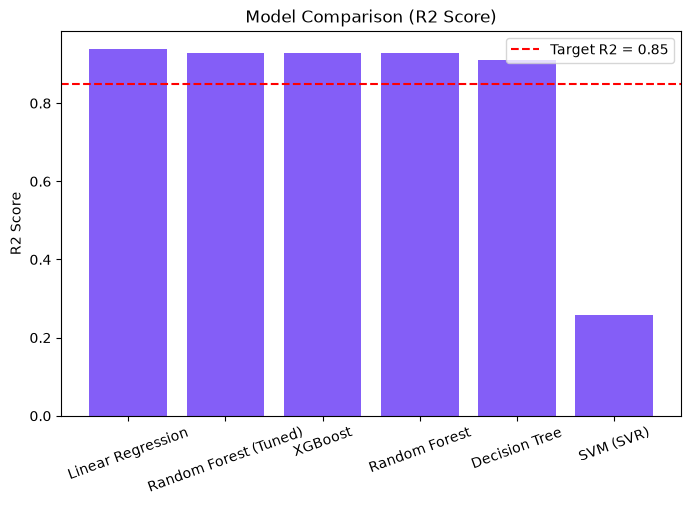

In [183]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["R2 Score"], color="#845EF7")
plt.axhline(0.85, color="red", linestyle="--", label="Target R2 = 0.85")
plt.xticks(rotation=20)
plt.ylabel("R2 Score")
plt.title("Model Comparison (R2 Score)")
plt.legend()
plt.show()

##  Best Model Selection

In [184]:
best_model_name = results.iloc[0]["Model"]
print("Best Model:", best_model_name)
print("R2 Score  :", results.iloc[0]["R2 Score"])

models_dict = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "SVM (SVR)": svm_model,
    "Random Forest (Tuned)": rf_tuned
}

best_model = models_dict[best_model_name]
best_model

Best Model: Linear Regression
R2 Score  : 0.9383165226759634


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](12,)","[2257.47,1750.21, 295.8 ,..., 127.81, 159.31, 163.57]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.807e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,12
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(12)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](12,)","[43.02,35.24,34.8 ,...,29.16,16.9 , 7.07]"


##  Save the Model



In [185]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

print("Model, scaler and feature columns saved successfully.")

Model, scaler and feature columns saved successfully.


##  Predict New Restaurant Revenue (Demo)

In [186]:
new_restaurant = pd.DataFrame([{
    "Number_of_Customers": 150,
    "Menu_Price": 30,
    "Marketing_Spend": 1200,
    "Average_Customer_Spending": 35,
    "Seating_Capacity": 80,
    "Promotions": 1,
    "Reviews": 200,
    "Customers_x_Spending": 150 * 35,
    "Cuisine_Type_Indian": 0,
    "Cuisine_Type_Italian": 1,
    "Cuisine_Type_Japanese": 0,
    "Cuisine_Type_Mexican": 0
}])[X.columns]

new_restaurant_scaled = scaler.transform(new_restaurant)
predicted_revenue = best_model.predict(new_restaurant_scaled)

print("Predicted Monthly Revenue =", predicted_revenue[0])

Predicted Monthly Revenue = 28485.71315405428
